In [ ]:
import sys
import subprocess
colab = False 

if "google.colab" in sys.modules:
    # Use Colab/Jupyter magic for installation
    colab = True
    %pip install -q scikit-image

import skimage as ski
import numpy as np

if colab:
    img = ski.io.imread("https://raw.githubusercontent.com/LOMA-AImotion/pdl_ss26/main/imaging/robos.jpg")
else: 
    img = ski.io.imread("robos.JPG")

    
import matplotlib.pyplot as plt

def imshow_matplotlib(image, cmap=None, **kwargs):
    plt.figure()
    if image.ndim == 2: # Grayscale image has only width and height as dimensions
        plt.imshow(image, cmap=cmap or "gray", **kwargs)
    else:
        plt.imshow(image, **kwargs)
    plt.axis("off")
    plt.show()

<class 'numpy.ndarray'>


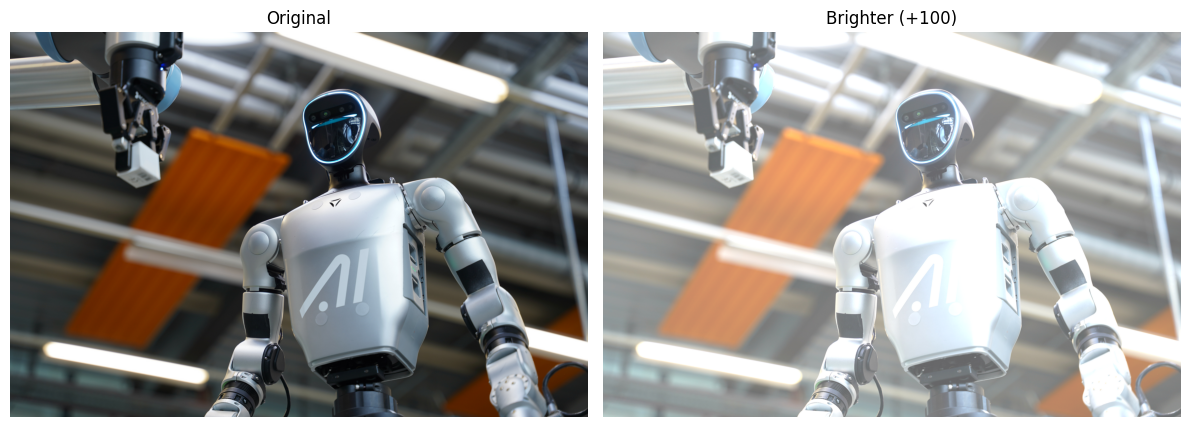

In [2]:
luminance_increment = 100
# cast to np.int16 to prevent overflow, then clip to [0, 255] and convert back to uint8 (0-255)
img_brighter = np.clip(img.astype(np.int16) + luminance_increment, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_brighter)
axes[1].set_title("Brighter (+100)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

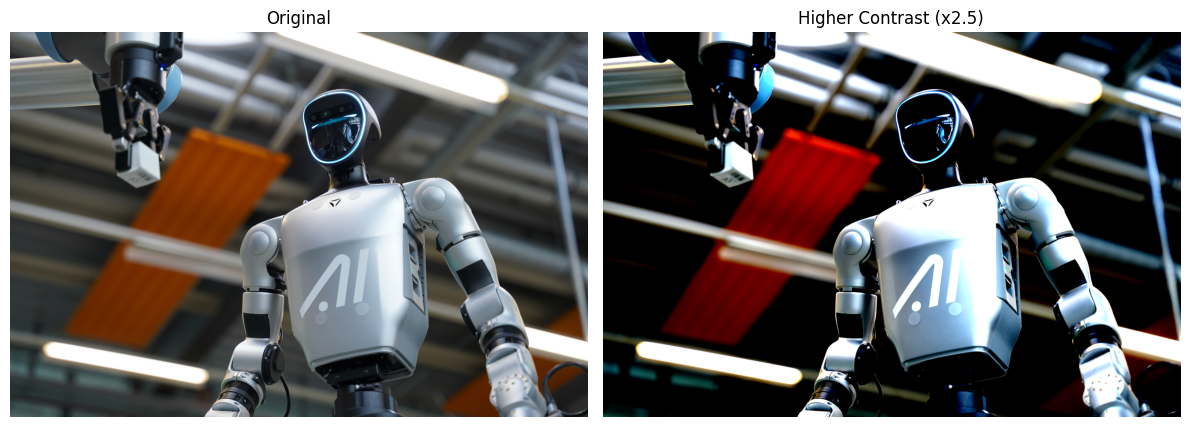

In [4]:
contrast_multiplier = 2.5
# scale contrast around mid-gray (128), then clip to [0, 255] and convert back to uint8
img_contrasted = np.clip((img.astype(np.float32) - 128) * contrast_multiplier + 128, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_contrasted)
axes[1].set_title(f"Higher Contrast (x{contrast_multiplier})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

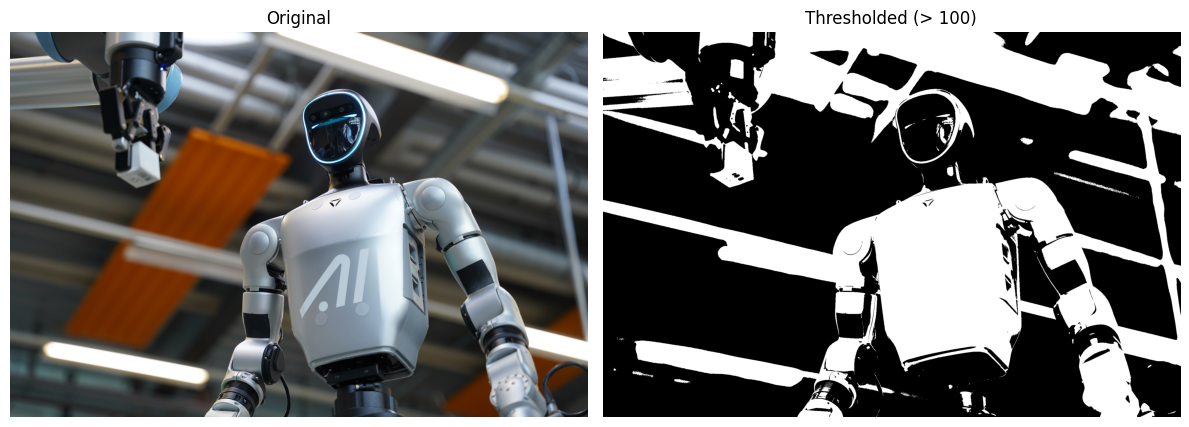

In [5]:
threshold_value = 100

# convert to grayscale and apply binary threshold
img_thresholded = np.where(img.mean(axis=2) > threshold_value, 255, 0).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_thresholded, cmap="gray")
axes[1].set_title(f"Thresholded (> {threshold_value})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [11]:
print(img.shape)
print(type(img))

(1667, 2500, 3)
<class 'numpy.ndarray'>


In [7]:
img_array = np.array(img)
print(type(img_array), img_array.shape, img_array.dtype)

<class 'numpy.ndarray'> (1667, 2500, 3) uint8
